# Notebook 02 — Analyse exploratoire (EDA) sur `features.parquet`

## Objectifs
1. Charger `data/processed/features.parquet` (matrice Kaggle feature-engineered).
2. Vérifier la séparation **train/test** via `TARGET`.
3. Comprendre :
   - la distribution / déséquilibre de la cible `TARGET`
   - les types de variables
   - la quantité de valeurs manquantes
   - la présence de doublons
   - des signaux de valeurs extrêmes (outliers)
   - des corrélations simples avec la cible

## Note méthodologique
- Le feature engineering est déjà effectué en amont (Notebook 01 + script).
- Les valeurs manquantes ne sont pas supprimées ici : elles seront gérées via une **imputation médiane dans la pipeline** d’entraînement (Partie modelling).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from credexp.config import DATA_DIR, settings
from credexp.data.io import load_parquet


In [2]:
features_path = DATA_DIR / "processed" / "features.parquet"
df = load_parquet(features_path)

df.shape


{"ts": "2026-02-18T19:58:08Z", "level": "INFO", "name": "credexp.data.io", "msg": "load_parquet path=G:\\Mon Drive\\OC\\Projet_6\\credexp\\data\\processed\\features.parquet"}


(356251, 797)

In [3]:
assert "TARGET" in df.columns, "TARGET column is missing!"

df_train = df[df["TARGET"].notna()].copy()
df_test = df[df["TARGET"].isna()].copy()

df_train.shape, df_test.shape


((307507, 797), (48744, 797))

## 1) Distribution de la cible (TARGET)

Dans Home Credit, la classe positive (défaut) est minoritaire.
On mesure :
- effectifs par classe
- taux de défaut
- visualisation simple


In [4]:
y = df_train["TARGET"].astype(int)

counts = y.value_counts().sort_index()
rate = y.mean()

counts, rate


(TARGET
 0    282682
 1     24825
 Name: count, dtype: int64,
 0.08072986956394489)

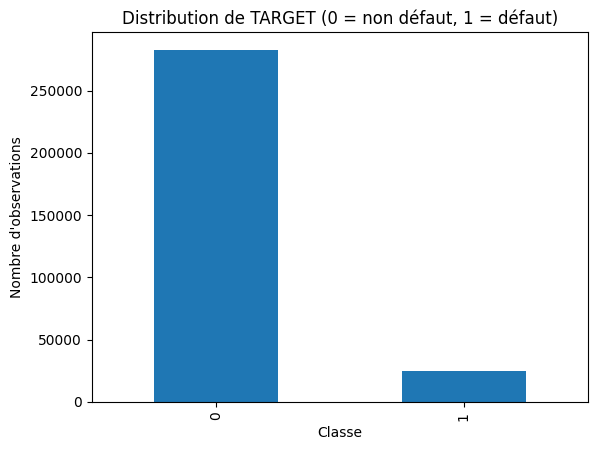

Taux de défaut (TARGET=1): 0.0807


In [5]:
plt.figure()
counts.plot(kind="bar")
plt.title("Distribution de TARGET (0 = non défaut, 1 = défaut)")
plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")
plt.show()

print(f"Taux de défaut (TARGET=1): {rate:.4f}")


## 2) Types de variables

Le kernel Kaggle produit majoritairement des variables numériques (float/int), issues :
- de features initiales
- de one-hot encoding
- d’agrégations statistiques par table

On vérifie la répartition des dtypes.


In [6]:
df_train.dtypes.value_counts()


float64    606
bool       133
int64       42
object      16
Name: count, dtype: int64

## 3) Valeurs manquantes

On mesure :
- le taux de valeurs manquantes par colonne
- les colonnes les plus touchées
- une visualisation `missingno` sur un échantillon

Décision :  
**On ne supprime pas** les colonnes ici.  
Les valeurs manquantes seront gérées via une **imputation médiane** dans la pipeline d’entraînement.


In [7]:
missing_rate = df_train.isna().mean().sort_values(ascending=False)
missing_rate.head(20)


REFUSED_AMT_DOWN_PAYMENT_MAX          0.853116
REFUSED_AMT_DOWN_PAYMENT_MEAN         0.853116
REFUSED_AMT_DOWN_PAYMENT_MIN          0.853116
REFUSED_RATE_DOWN_PAYMENT_MEAN        0.853116
REFUSED_RATE_DOWN_PAYMENT_MAX         0.853116
REFUSED_RATE_DOWN_PAYMENT_MIN         0.853116
REFUSED_APP_CREDIT_PERC_VAR           0.840143
CC_AMT_PAYMENT_CURRENT_VAR            0.802870
CC_CNT_DRAWINGS_POS_CURRENT_VAR       0.802629
CC_AMT_DRAWINGS_OTHER_CURRENT_VAR     0.802629
CC_CNT_DRAWINGS_OTHER_CURRENT_VAR     0.802629
CC_AMT_DRAWINGS_POS_CURRENT_VAR       0.802629
CC_CNT_DRAWINGS_ATM_CURRENT_VAR       0.802629
CC_AMT_DRAWINGS_ATM_CURRENT_VAR       0.802629
CC_AMT_PAYMENT_CURRENT_MEAN           0.801435
CC_AMT_PAYMENT_CURRENT_MAX            0.801435
CC_AMT_PAYMENT_CURRENT_MIN            0.801435
CC_AMT_DRAWINGS_OTHER_CURRENT_MEAN    0.801175
CC_AMT_DRAWINGS_OTHER_CURRENT_MAX     0.801175
CC_AMT_DRAWINGS_POS_CURRENT_MIN       0.801175
dtype: float64

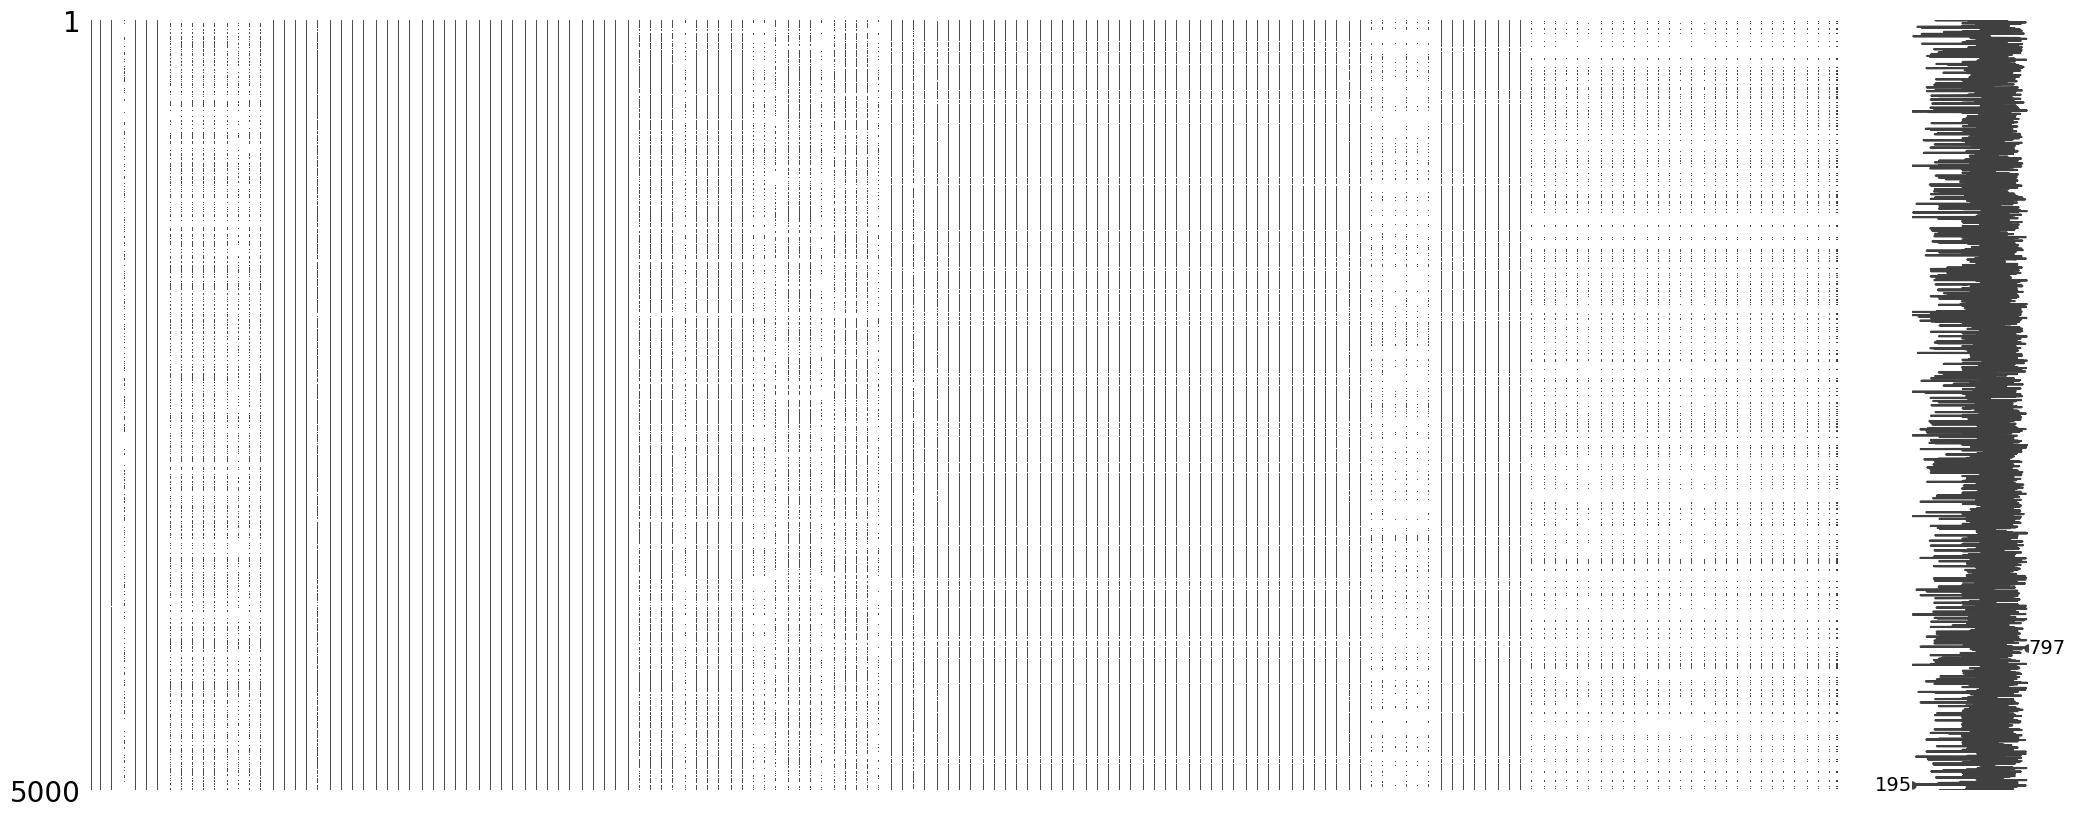

In [8]:
sample = df_train.sample(n=min(5000, len(df_train)), random_state=settings.random_state)
msno.matrix(sample)
plt.show()


In [9]:
high_missing = missing_rate[missing_rate > 0.8]
len(high_missing), high_missing.head(10)


(37,
 REFUSED_AMT_DOWN_PAYMENT_MAX         0.853116
 REFUSED_AMT_DOWN_PAYMENT_MEAN        0.853116
 REFUSED_AMT_DOWN_PAYMENT_MIN         0.853116
 REFUSED_RATE_DOWN_PAYMENT_MEAN       0.853116
 REFUSED_RATE_DOWN_PAYMENT_MAX        0.853116
 REFUSED_RATE_DOWN_PAYMENT_MIN        0.853116
 REFUSED_APP_CREDIT_PERC_VAR          0.840143
 CC_AMT_PAYMENT_CURRENT_VAR           0.802870
 CC_CNT_DRAWINGS_POS_CURRENT_VAR      0.802629
 CC_AMT_DRAWINGS_OTHER_CURRENT_VAR    0.802629
 dtype: float64)

## 4) Doublons

Deux notions :
1. Doublons de clé `SK_ID_CURR` : normalement, on doit avoir **1 ligne par client**.
2. Doublons exacts (lignes identiques) : plus rares, mais on vérifie.

On commence par vérifier l’unicité de `SK_ID_CURR`.


In [10]:
key = "SK_ID_CURR"

n_total = len(df_train)
n_unique = df_train[key].nunique()
n_total, n_unique, n_total - n_unique


(307507, 307507, 0)

In [11]:
dup_keys = df_train[key].value_counts()
dup_keys = dup_keys[dup_keys > 1]
dup_keys.head()


Series([], Name: count, dtype: int64)

In [12]:
exact_dups = df_train.duplicated().sum()
exact_dups


0

## 5) Valeurs extrêmes / outliers

Sur des données financières, certaines valeurs peuvent être très asymétriques.
On fait un check simple :
- quantiles (1%, 99%)
- méthode IQR sur quelques variables clés
- visualisation (boxplot / histogram)

Objectif : détecter les variables à transformer (log) ou à contrôler dans la pipeline.


In [13]:
candidate_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "DAYS_BIRTH", "DAYS_EMPLOYED"]
candidate_cols = [c for c in candidate_cols if c in df_train.columns]

df_train[candidate_cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,50%,95%,99%,max
AMT_INCOME_TOTAL,307507.0,168797.685779,237124.627320,25650.0,45000.00,67500.0,147150.0,337500.0,472500.0,117000000.0
AMT_CREDIT,307507.0,599028.596733,402492.601859,45000.0,76410.00,135000.0,513531.0,1350000.0,1854000.0,4050000.0
AMT_ANNUITY,307495.0,27108.666786,14493.798379,1615.5,6182.73,9000.0,24903.0,53325.0,70006.5,258025.5
DAYS_BIRTH,307507.0,-16037.027271,4363.982424,-25229.0,-24419.00,-23204.0,-15750.0,-9407.0,-8263.0,-7489.0
DAYS_EMPLOYED,252133.0,-2384.142254,2338.327666,-17912.0,-11338.36,-7291.0,-1648.0,-206.0,-111.0,0.0


In [14]:
def iqr_outlier_rate(s: pd.Series) -> float:
    s = s.dropna()
    if s.empty:
        return 0.0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return float(((s < lo) | (s > hi)).mean())

outlier_rates = {c: iqr_outlier_rate(df_train[c]) for c in candidate_cols}
pd.Series(outlier_rates).sort_values(ascending=False)


DAYS_EMPLOYED       0.060079
AMT_INCOME_TOTAL    0.045641
AMT_ANNUITY         0.024404
AMT_CREDIT          0.021339
DAYS_BIRTH          0.000000
dtype: float64

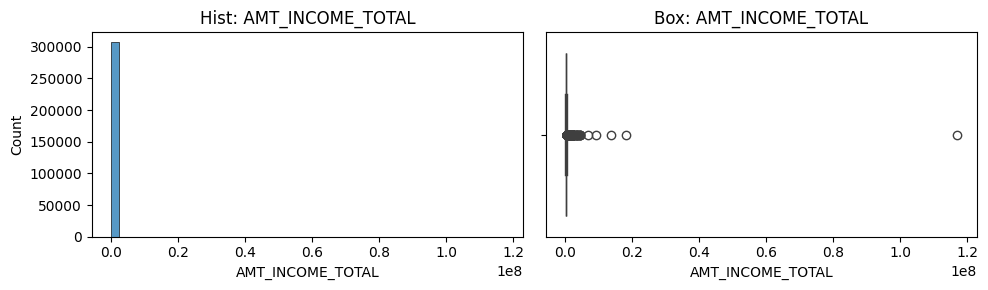

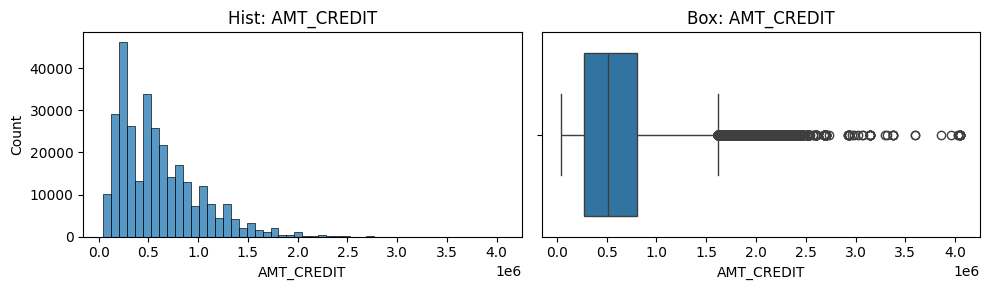

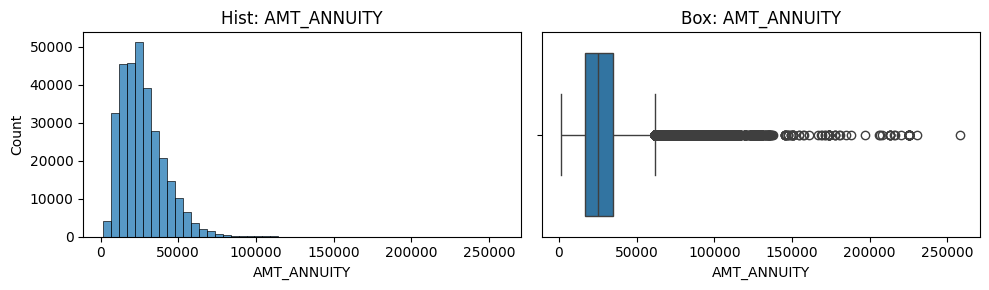

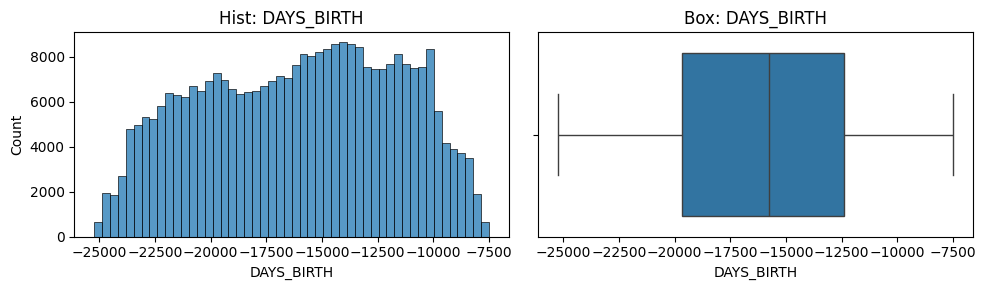

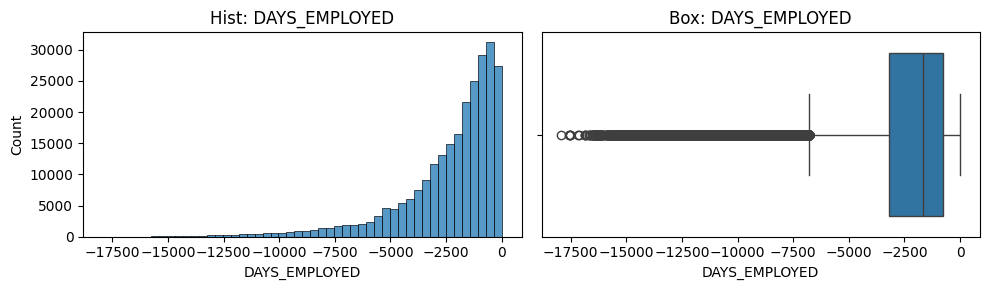

In [15]:
for c in candidate_cols:
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df_train[c].dropna(), bins=50, ax=ax[0])
    ax[0].set_title(f"Hist: {c}")

    sns.boxplot(x=df_train[c].dropna(), ax=ax[1])
    ax[1].set_title(f"Box: {c}")

    plt.tight_layout()
    plt.show()


## 6) Corrélations (subset)

On ne calcule pas une heatmap sur 700+ features (illisible).
On fait :
1. Corrélations avec `TARGET` et on affiche le top
2. Heatmap sur un sous-ensemble (top variables en valeur absolue)

> Attention : corrélation ≠ causalité.


In [16]:
train_numeric = df_train.select_dtypes(include=[np.number]).copy()
corr_with_target = train_numeric.corr()["TARGET"].drop("TARGET").sort_values()

top_neg = corr_with_target.head(10)
top_pos = corr_with_target.tail(10)

top_neg, top_pos


(EXT_SOURCE_3                              -0.178926
 EXT_SOURCE_2                              -0.160471
 EXT_SOURCE_1                              -0.155317
 BURO_MONTHS_BALANCE_SIZE_MEAN             -0.080193
 BURO_CREDIT_ACTIVE_Closed_MEAN            -0.079369
 PREV_CODE_REJECT_REASON_XAP_MEAN          -0.073938
 DAYS_EMPLOYED_PERC                        -0.067952
 ACTIVE_MONTHS_BALANCE_SIZE_MEAN           -0.065154
 PREV_NAME_CONTRACT_STATUS_Approved_MEAN   -0.063526
 CC_COUNT                                  -0.060481
 Name: TARGET, dtype: float64,
 PREV_NAME_PRODUCT_TYPE_nan_MEAN      NaN
 PREV_CHANNEL_TYPE_nan_MEAN           NaN
 PREV_NAME_SELLER_INDUSTRY_nan_MEAN   NaN
 PREV_NAME_YIELD_GROUP_nan_MEAN       NaN
 POS_NAME_CONTRACT_STATUS_nan_MEAN    NaN
 CC_SK_DPD_MIN                        NaN
 CC_SK_DPD_DEF_MIN                    NaN
 CC_NAME_CONTRACT_STATUS_nan_MEAN     NaN
 CC_NAME_CONTRACT_STATUS_nan_SUM      NaN
 CC_NAME_CONTRACT_STATUS_nan_VAR      NaN
 Name: TARGET, dtyp

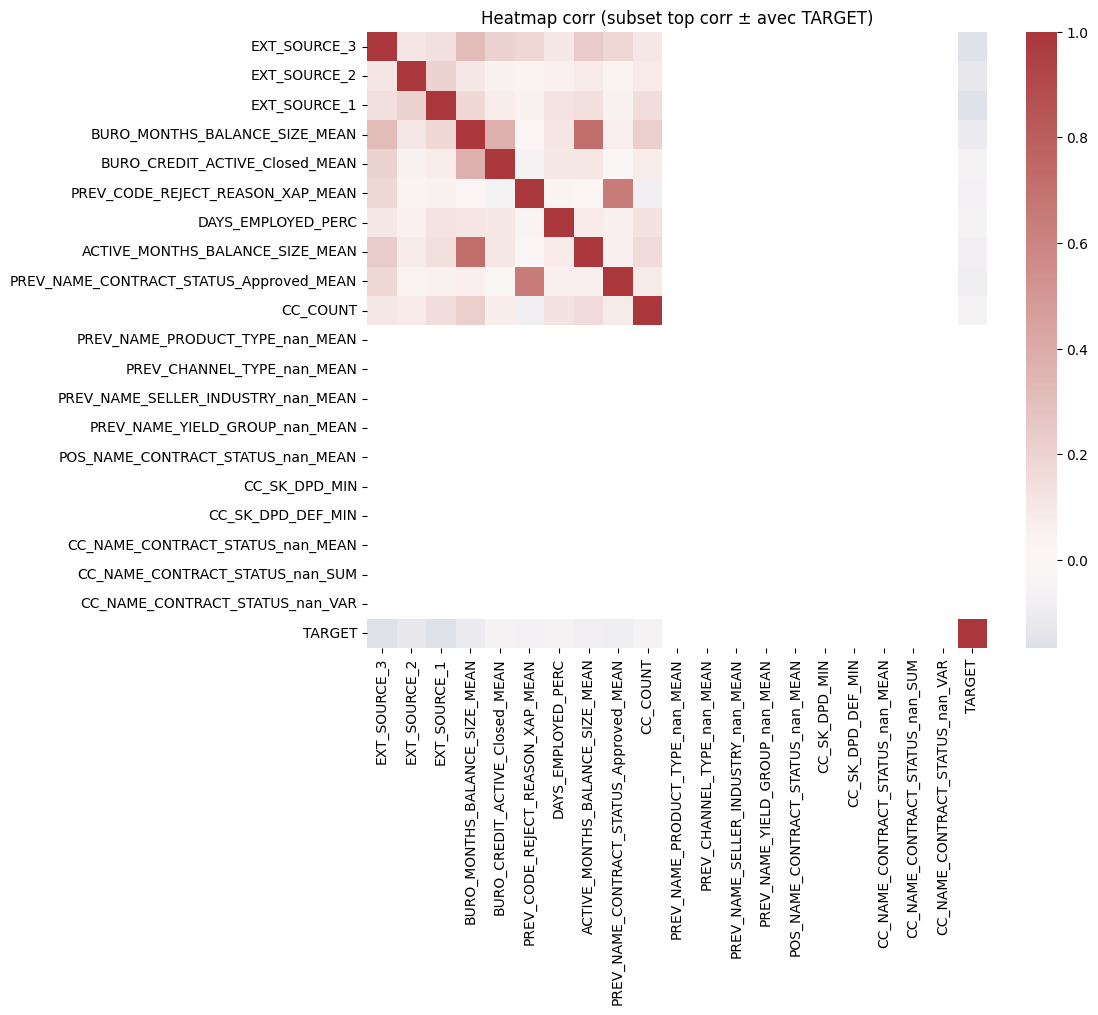

In [17]:
top_features = list(top_neg.index) + list(top_pos.index) + ["TARGET"]
subset = train_numeric[top_features].dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(subset.corr(), center=0, cmap="vlag", annot=False)
plt.title("Heatmap corr (subset top corr ± avec TARGET)")
plt.show()


## 7) Sauvegarde d’un dataset de référence (monitoring)

Pour la Partie 2 (monitoring / drift), on sauvegarde un échantillon de train.
Ce dataset de référence servira à comparer les distributions futures (production).


In [18]:
ref_path = DATA_DIR / "processed" / "reference.parquet"
ref = df_train.sample(n=min(20000, len(df_train)), random_state=settings.random_state)
ref.to_parquet(ref_path, index=False)
ref_path


WindowsPath('G:/Mon Drive/OC/Projet_6/credexp/data/processed/reference.parquet')

## Conclusion

- La cible `TARGET` est fortement déséquilibrée → on utilisera des stratégies adaptées (pondération / undersampling).
- La matrice contient majoritairement des variables numériques (issues du kernel Kaggle).
- Les valeurs manquantes sont fréquentes sur certaines features → elles seront traitées par **imputation médiane** dans la pipeline.
- Pas de doublons inattendus sur `SK_ID_CURR` (à confirmer par le check).
- Quelques variables présentent une forte dispersion → à garder en tête pour l’entraînement (robustesse, calibration, seuil métier).
- Les corrélations simples donnent des premières pistes, sans remplacer une évaluation modèle rigoureuse.

Prochaine étape : entraînement + tracking MLflow (Notebook 03).
